In [1]:
import pandas as pd

recipes = pd.read_csv("../data/13k-recipes.csv")
calories = pd.read_csv("../data/calories.csv")
ingredients = pd.read_csv("../data/Detail ingredient.csv")
nutrition_1 = pd.read_csv("../data/Food Nutri.csv")
nutrition_2 = pd.read_csv("../data/Food Nutri 2.csv")
diet_recommendations = pd.read_csv("../data/Personalized_Diet_Recommendations.csv")

In [2]:
# recipes.head()
# calories.head()
# ingredients.head()
# nutrition_1.head()
# nutrition_2.head()
# diet_recommendations.head()

## Exploratory Data Analysis (EDA)

เป้าหมายของ EDA ชุดนี้:
- ตรวจสอบโครงสร้างและคุณภาพข้อมูล
- สำรวจการกระจายตัวและความสัมพันธ์ของตัวแปร
- สรุปประเด็นที่ต้องจัดการก่อนขั้นตอน modeling

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

# Optional: seaborn for better plots
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

DATASETS = {
    "recipes": recipes,
    "calories": calories,
    "ingredients": ingredients,
    "nutrition_1": nutrition_1,
    "nutrition_2": nutrition_2,
    "diet_recommendations": diet_recommendations,
}

print(f"Loaded {len(DATASETS)} datasets")

Loaded 6 datasets


In [4]:
# 1) Data overview (rows, columns, memory, column type counts)
overview_rows = []
for name, df in DATASETS.items():
    dtype_counts = df.dtypes.astype(str).value_counts().to_dict()
    overview_rows.append(
        {
            "dataset": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "memory_mb": round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2),
            "dtype_counts": dtype_counts,
        }
    )

overview = pd.DataFrame(overview_rows).sort_values(by=["rows", "columns"], ascending=False)
overview

,dataset,rows,columns,memory_mb,dtype_counts
3,nutrition_1,40000,24,33.12,"{'float64': 13, 'str': 9, 'int64': 2}"
0,recipes,13501,6,33.13,"{'str': 5, 'int64': 1}"
2,ingredients,8789,77,34.27,"{'str': 74, 'int64': 3}"
4,nutrition_2,7806,8,2.50,"{'str': 5, 'float64': 3}"
5,diet_recommendations,5000,30,3.47,"{'int64': 17, 'str': 11, 'float64': 2}"
1,calories,2225,5,0.61,{'str': 5}


In [5]:
# 2) Data quality check (missing values, duplicates, uniqueness)
def data_quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    total_rows = len(df)
    null_count = df.isna().sum()
    null_pct = (
        (null_count / total_rows * 100).round(2)
        if total_rows
        else pd.Series(0.0, index=df.columns)
    )
    nunique = df.nunique(dropna=True)

    report = pd.DataFrame(
        {
            "dataset": name,
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "missing_count": null_count.values,
            "missing_pct": null_pct.values,
            "nunique": nunique.values,
        }
    )
    return report.sort_values("missing_pct", ascending=False)

quality_reports = {name: data_quality_report(df, name) for name, df in DATASETS.items()}

for name, report in quality_reports.items():
    dup_count = DATASETS[name].duplicated().sum()
    print(f"\n{name} | duplicates: {dup_count}")
    display(report.head(10))


recipes | duplicates: 0


,dataset,column,dtype,missing_count,missing_pct,nunique
3,recipes,Instructions,str,8,0.06,13464
1,recipes,Title,str,5,0.04,13305
0,recipes,Unnamed: 0,int64,0,0.00,13501
2,recipes,Ingredients,str,0,0.00,13473
4,recipes,Image_Name,str,0,0.00,13472
5,recipes,Cleaned_Ingredients,str,0,0.00,13473



calories | duplicates: 1


,dataset,column,dtype,missing_count,missing_pct,nunique
0,calories,FoodCategory,str,0,0.0,44
1,calories,FoodItem,str,0,0.0,1993
2,calories,per100grams,str,0,0.0,2
3,calories,Cals_per100grams,str,0,0.0,524
4,calories,KJ_per100grams,str,0,0.0,524



ingredients | duplicates: 0


...

,dataset,column,dtype,missing_count,missing_pct,nunique
16,nutrition_1,vitamin_c_mg,float64,17060,42.65,824
5,nutrition_1,brand_name,str,9746,24.36,7170
9,nutrition_1,household_serving,str,9210,23.02,4221
4,nutrition_1,brand_owner,str,8617,21.54,5552
6,nutrition_1,ingredients,str,8344,20.86,24684
8,nutrition_1,serving_unit,str,8158,20.40,8
7,nutrition_1,serving_size,float64,8158,20.40,635
17,nutrition_1,fiber_g,float64,6275,15.69,520
21,nutrition_1,cholesterol_mg,float64,5842,14.60,558
12,nutrition_1,calcium_mg,float64,5785,14.46,1034



nutrition_2 | duplicates: 5


,dataset,column,dtype,missing_count,missing_pct,nunique
0,nutrition_2,Diet_type,str,0,0.0,5
1,nutrition_2,Recipe_name,str,0,0.0,7062
2,nutrition_2,Cuisine_type,str,0,0.0,19
3,nutrition_2,Protein(g),float64,0,0.0,6060
4,nutrition_2,Carbs(g),float64,0,0.0,6618
5,nutrition_2,Fat(g),float64,0,0.0,6322
6,nutrition_2,Extraction_day,str,0,0.0,1
7,nutrition_2,Extraction_time,str,0,0.0,496



diet_recommendations | duplicates: 0


,dataset,column,dtype,missing_count,missing_pct,nunique
12,diet_recommendations,Allergies,str,3497,69.94,3
6,diet_recommendations,Chronic_Disease,str,2043,40.86,4
24,diet_recommendations,Food_Aversions,str,1225,24.50,3
2,diet_recommendations,Gender,str,0,0.00,3
0,diet_recommendations,Patient_ID,str,0,0.00,5000
3,diet_recommendations,Height_cm,int64,0,0.00,50
5,diet_recommendations,BMI,float64,0,0.00,1800
4,diet_recommendations,Weight_kg,int64,0,0.00,70
8,diet_recommendations,Blood_Pressure_Diastolic,int64,0,0.00,60
7,diet_recommendations,Blood_Pressure_Systolic,int64,0,0.00,90


## 3) Core EDA (All Datasets)

ส่วนนี้เป็น EDA แบบมาตรฐานที่ไม่ลึกเกินไป:
- Distribution: histogram ของคอลัมน์ตัวเลขที่สำคัญ
- Correlation: heatmap เฉพาะคอลัมน์ตัวเลข
- Outlier: boxplot + IQR summary

เพื่อให้ดูง่ายและรันเร็ว จะจำกัดจำนวนคอลัมน์ที่ plot ต่อ dataset

EDA: recipes
No numeric columns for EDA in this dataset.
EDA: calories
No numeric columns for EDA in this dataset.
EDA: ingredients
Numeric columns used: 1


,count,mean,std,min,25%,50%,75%,max
calories,8789.0,226.283878,169.862001,0.0,91.0,191.0,337.0,902.0


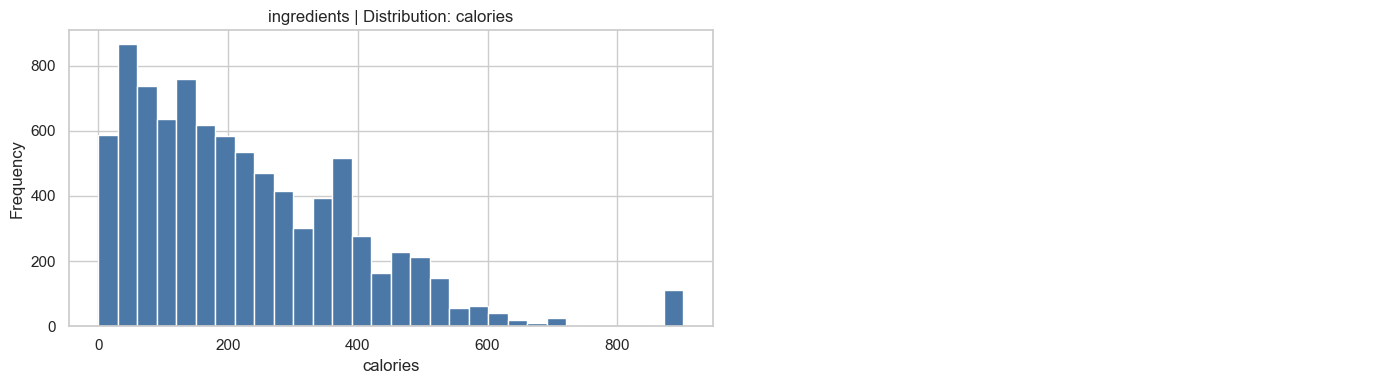

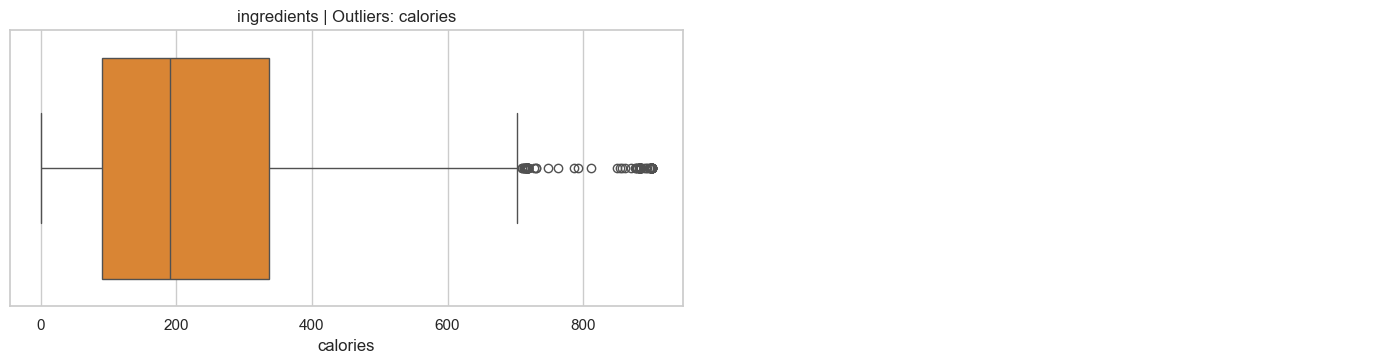

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
0,calories,148,1.68


EDA: nutrition_1
Numeric columns used: 14


,count,mean,std,min,25%,50%,75%,max
sodium_mg,39383.0,1067.232571,28957.009538,0.0,16.0,143.0,481.0,4690000.0
cholesterol_mg,34158.0,62.575833,2141.337343,0.0,0.0,0.0,38.0,214000.0
vitamin_c_mg,22940.0,24.138259,1419.157682,0.0,0.0,0.0,5.2,210000.0
calcium_mg,34215.0,106.091172,1327.632746,0.0,5.0,29.0,98.0,150000.0


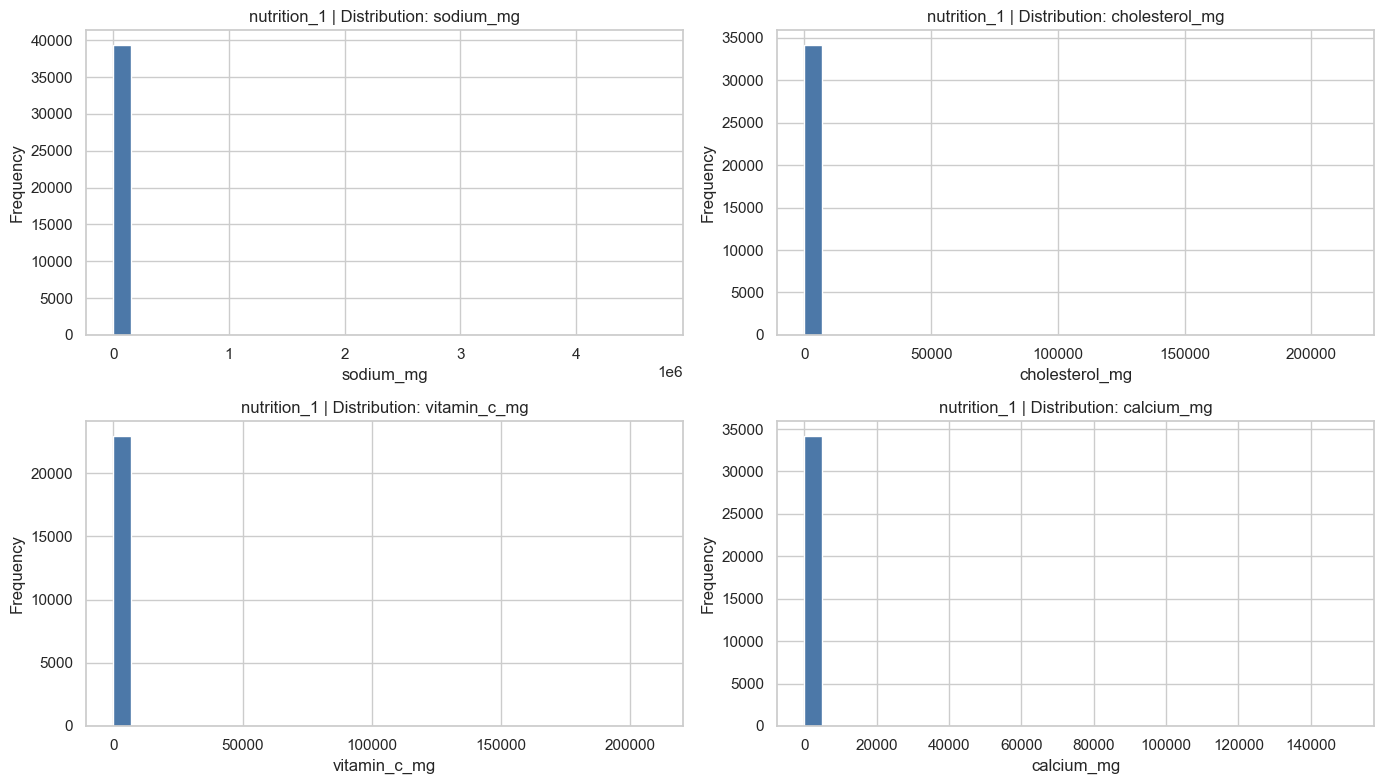

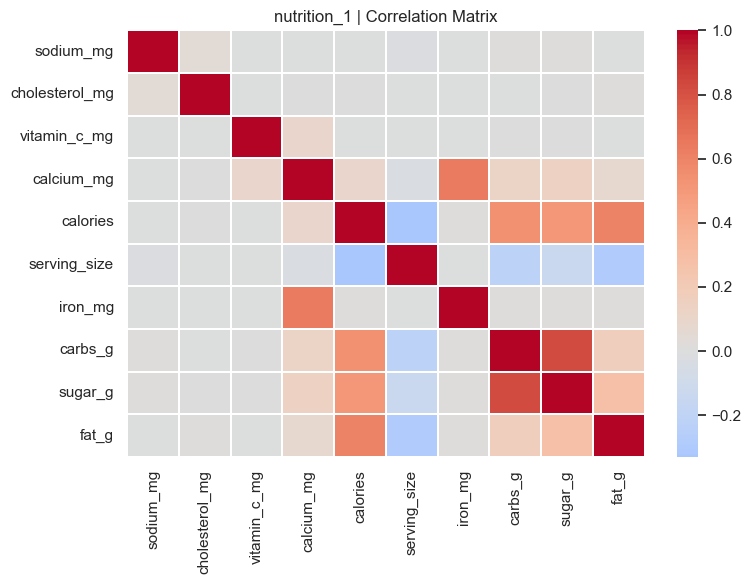

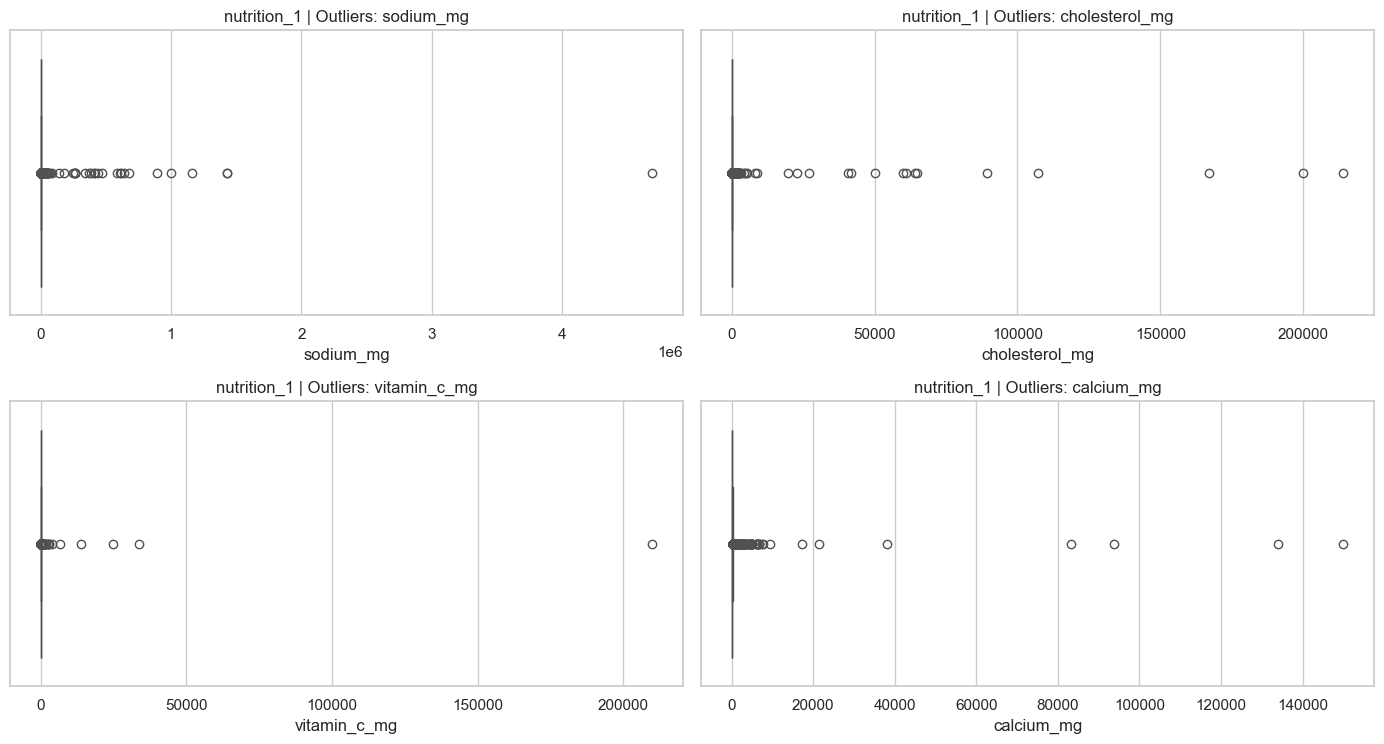

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
7,vitamin_c_mg,3953,17.23
11,sugar_g,3575,10.00
8,fiber_g,2536,7.52
6,saturated_fat_g,2560,7.31
3,calcium_mg,2482,7.25
10,sodium_mg,2424,6.15
12,cholesterol_mg,1806,5.29
4,fat_g,2017,5.08
0,serving_size,1430,4.49
9,iron_mg,1475,4.31


EDA: nutrition_2
Numeric columns used: 3


,count,mean,std,min,25%,50%,75%,max
Carbs(g),7806.0,152.123189,185.907322,0.06,36.1625,93.415,205.9150,3405.55
Fat(g),7806.0,117.328542,122.098117,0.00,41.0675,84.865,158.2900,1930.24
Protein(g),7806.0,83.231498,89.797282,0.00,24.4150,56.280,112.3575,1273.61


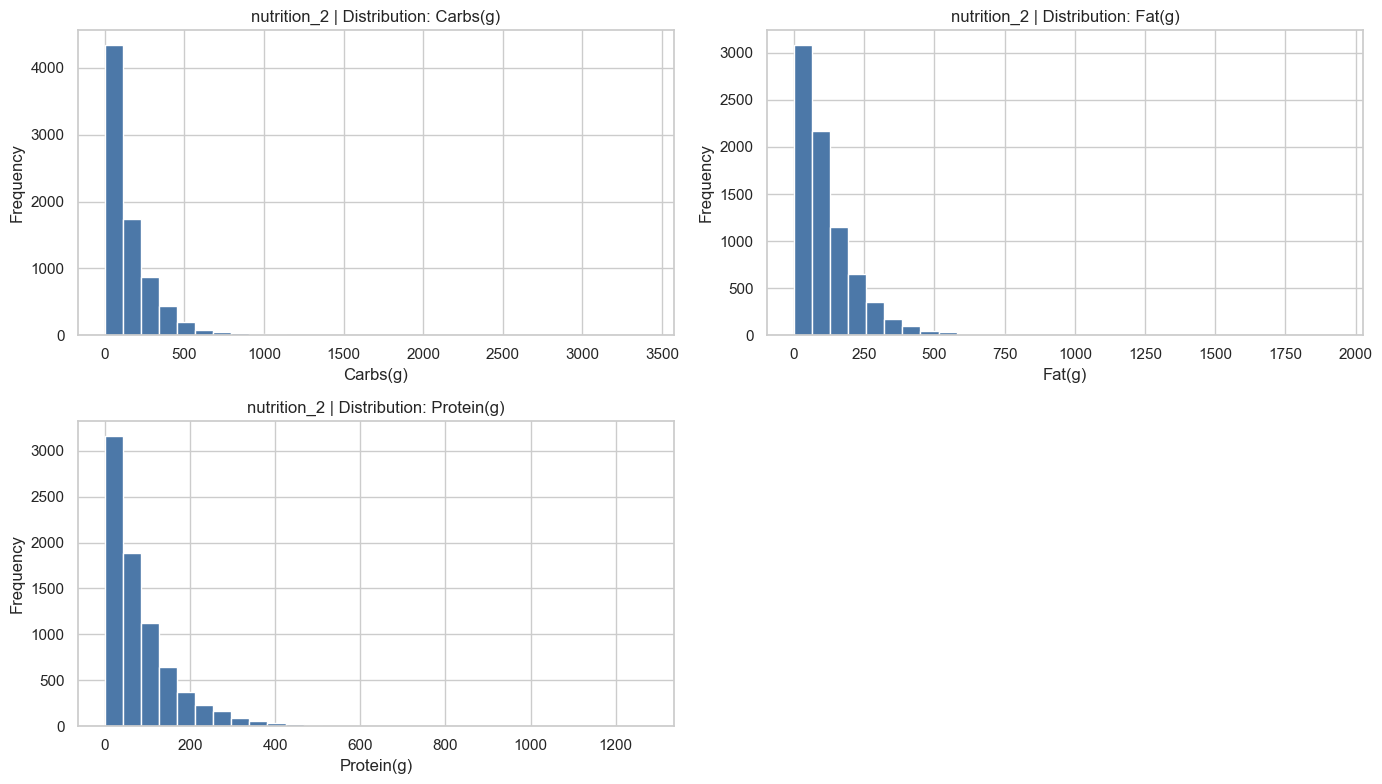

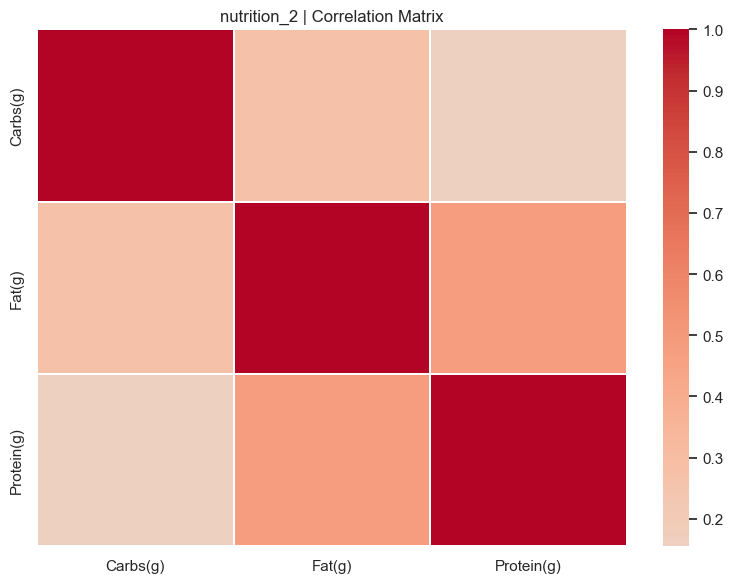

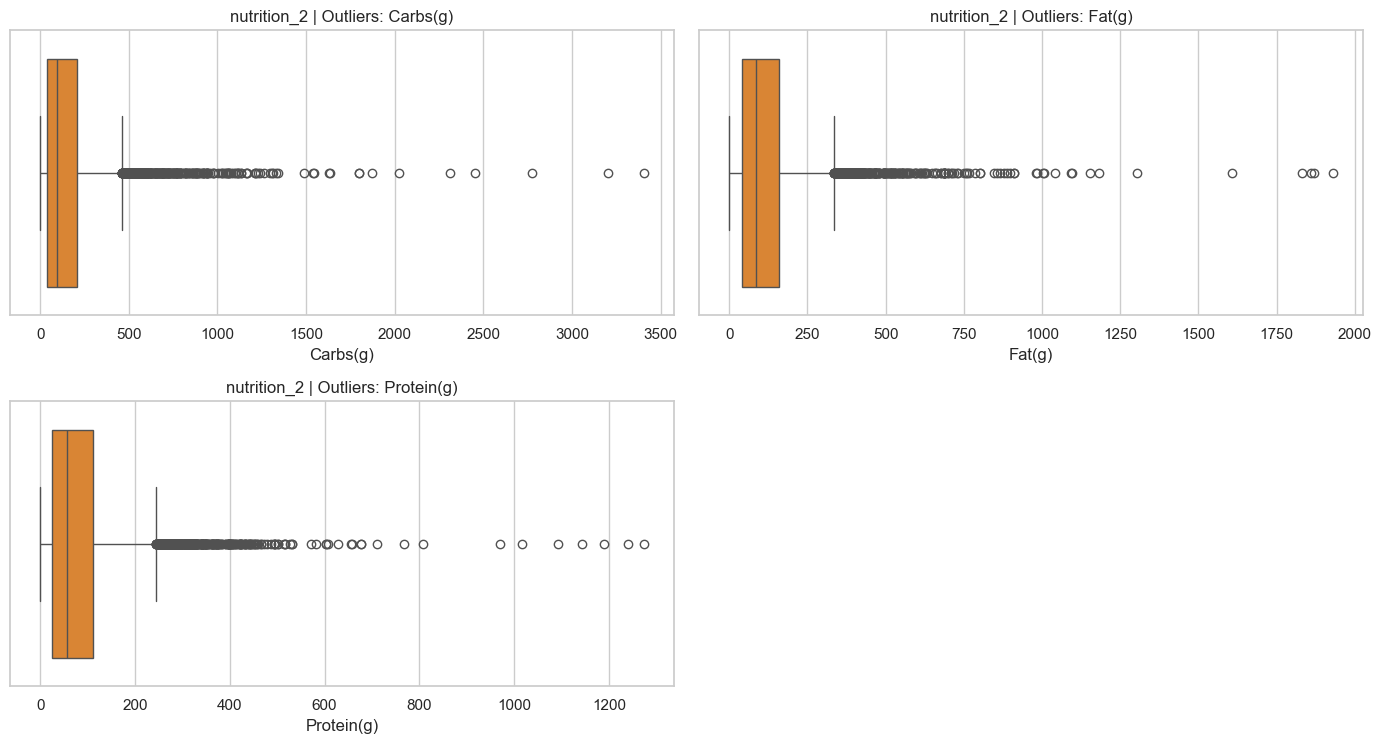

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
0,Protein(g),440,5.64
1,Carbs(g),410,5.25
2,Fat(g),359,4.60


EDA: diet_recommendations
Numeric columns used: 19


,count,mean,std,min,25%,50%,75%,max
Daily_Steps,5000.0,8458.9228,3742.408853,2004.0,5278.75,8452.0,11671.75,14997.0
Recommended_Calories,5000.0,2046.2360,671.380142,725.0,1478.00,2044.0,2621.00,3372.0
Caloric_Intake,5000.0,2347.3502,659.880146,1200.0,1777.00,2350.5,2921.25,3499.0
Recommended_Carbs,5000.0,248.3286,91.152909,50.0,173.00,246.0,324.00,447.0


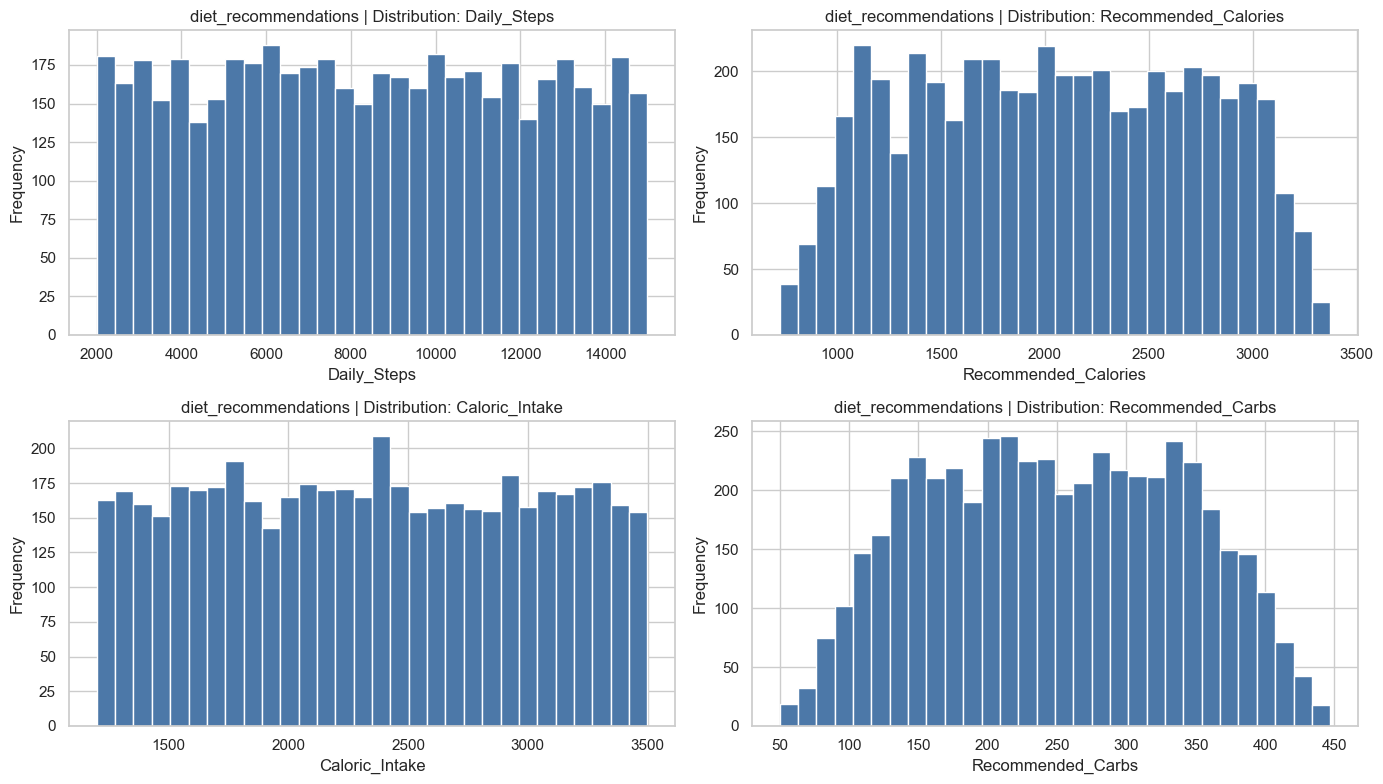

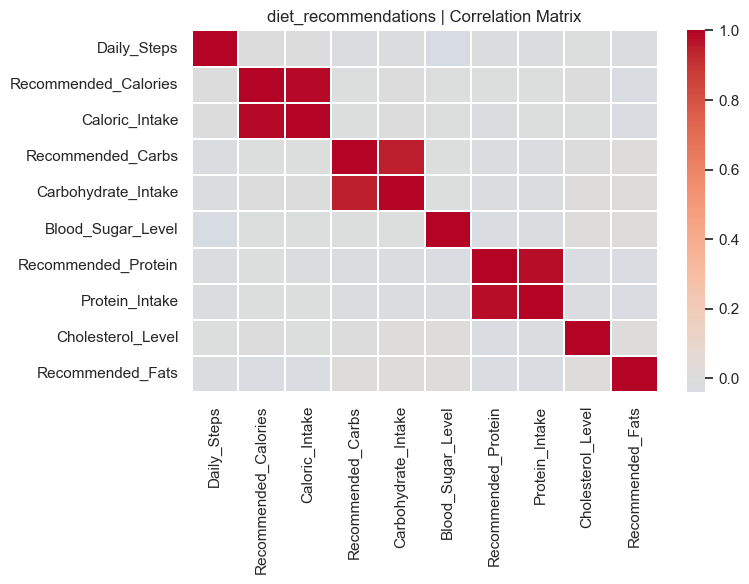

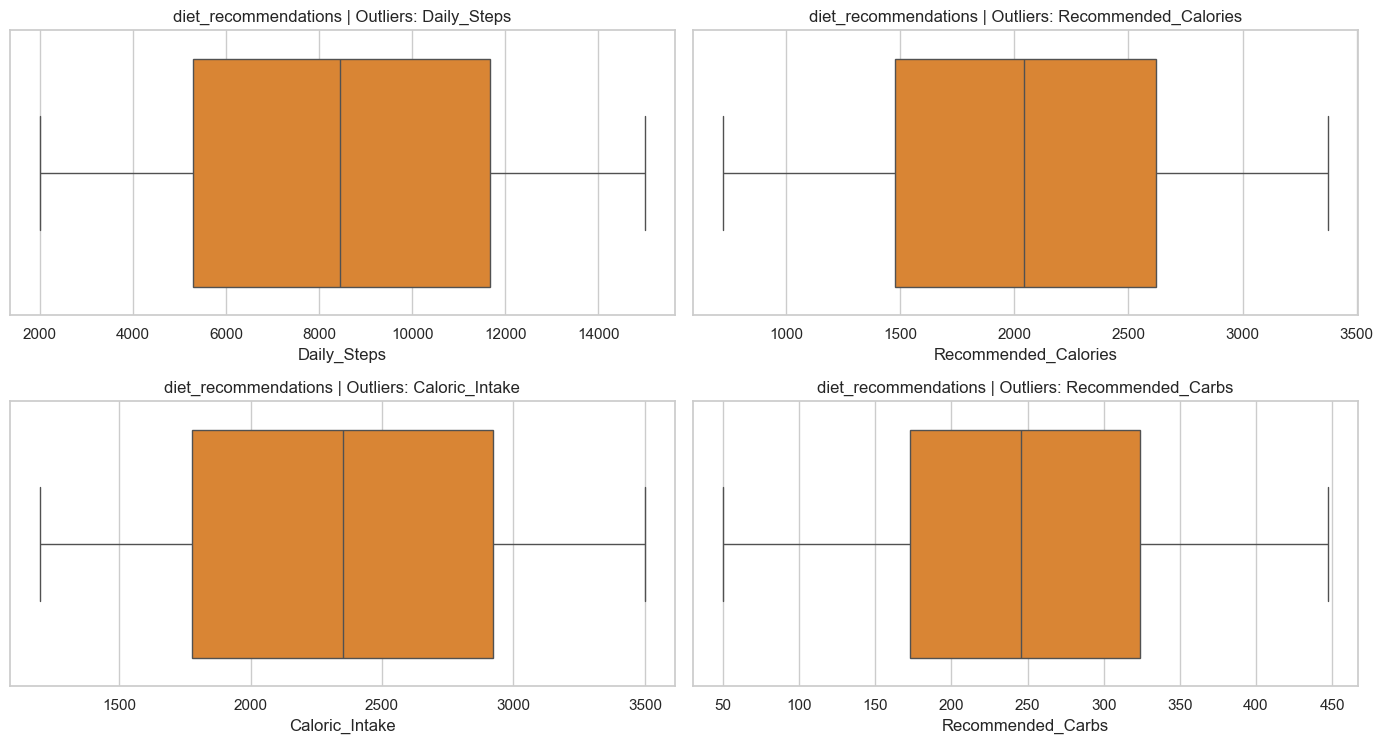

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
3,BMI,4,0.08
1,Height_cm,0,0.00
0,Age,0,0.00
2,Weight_kg,0,0.00
4,Blood_Pressure_Systolic,0,0.00
5,Blood_Pressure_Diastolic,0,0.00
6,Cholesterol_Level,0,0.00
7,Blood_Sugar_Level,0,0.00
8,Daily_Steps,0,0.00
9,Exercise_Frequency,0,0.00


In [6]:
# 3.1) Distribution + Correlation + Outlier (simple and clear)
from math import ceil

MAX_PLOTS_PER_DATASET = 4
BINS = 30

for dataset_name, df in DATASETS.items():
    print("=" * 90)
    print(f"EDA: {dataset_name}")

    num_df = df.select_dtypes(include=np.number).copy()

    # Remove index/id-like columns and constant columns for cleaner EDA.
    keep_cols = []
    for col in num_df.columns:
        col_lower = str(col).lower()
        is_id_like = col_lower.startswith("unnamed") or col_lower == "id" or col_lower.endswith("_id")
        is_constant = num_df[col].nunique(dropna=True) <= 1
        if not is_id_like and not is_constant:
            keep_cols.append(col)

    num_df = num_df[keep_cols]

    if num_df.empty:
        print("No numeric columns for EDA in this dataset.")
        continue

    # Use top columns by variation so plots are informative but not overwhelming.
    ordered_cols = num_df.std(numeric_only=True).sort_values(ascending=False).index.tolist()
    plot_cols = ordered_cols[:MAX_PLOTS_PER_DATASET]

    print(f"Numeric columns used: {num_df.shape[1]}")
    display(num_df[plot_cols].describe().T)

    # 1) Distribution
    nrows = ceil(len(plot_cols) / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        axes[i].hist(num_df[col].dropna(), bins=BINS, color="#4C78A8", edgecolor="white")
        axes[i].set_title(f"{dataset_name} | Distribution: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for i in range(len(plot_cols), len(axes)):
        axes[i].axis("off")

    fig.tight_layout()
    plt.show()

    # 2) Correlation
    if num_df.shape[1] >= 2:
        corr_cols = ordered_cols[: min(10, len(ordered_cols))]
        corr = num_df[corr_cols].corr(numeric_only=True)

        plt.figure(figsize=(8, 6))
        if sns is not None:
            sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
        else:
            plt.imshow(corr, cmap="coolwarm", aspect="auto")
            plt.colorbar(label="Correlation")
            plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
            plt.yticks(range(len(corr.index)), corr.index)
        plt.title(f"{dataset_name} | Correlation Matrix")
        plt.tight_layout()
        plt.show()

    # 3) Outlier
    nrows = ceil(len(plot_cols) / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        s = num_df[col].dropna()
        if sns is not None:
            sns.boxplot(x=s, ax=axes[i], color="#F58518")
        else:
            axes[i].boxplot(s, vert=False)
        axes[i].set_title(f"{dataset_name} | Outliers: {col}")
        axes[i].set_xlabel(col)

    for i in range(len(plot_cols), len(axes)):
        axes[i].axis("off")

    fig.tight_layout()
    plt.show()

    # IQR summary (quick table)
    outlier_rows = []
    for col in num_df.columns:
        s = num_df[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((s < lower) | (s > upper)).sum())
        outlier_rows.append(
            {
                "feature": col,
                "outlier_count": outlier_count,
                "outlier_pct": round(outlier_count / len(s) * 100, 2),
            }
        )

    outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
    print("Outlier summary (IQR):")
    display(outlier_summary.head(10))